# Visualización de datos preprocesados

Lee los datos de `output/preprocessed/{train,val,test}/` generados por `preprocessing_pipeline.py` y permite verificar visualmente que el preprocesamiento es correcto.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
output_dir = "../../output"
split = "train"  # Cambiar a "val" o "test" para ver otros splits

split_dir = os.path.join(output_dir, "preprocessed", split)
meta = pd.read_csv(os.path.join(split_dir, "metadata.csv"))

print(f"Split: {split}")
print(f"Nódulos: {len(meta)}")
print(f"Pacientes: {meta.patient_id.nunique()}")
meta.head(10)

Split: train
Nódulos: 525
Pacientes: 193


,patient_id,nodule_idx,num_annotations,vol_shape,bbox_x,bbox_y,bbox_z,subtlety,internalStructure,calcification,sphericity,margin,lobulation,spiculation,texture,malignancy
0,LIDC-IDRI-0069,0,4,"(512, 512, 136)",359-385,158-177,36-45,2.50,1.0,6.00,4.50,4.25,4.00,4.00,4.75,3.25
1,LIDC-IDRI-0069,1,1,"(512, 512, 136)",337-343,223-230,52-53,2.00,1.0,6.00,4.00,4.00,5.00,5.00,5.00,2.00
2,LIDC-IDRI-0069,2,4,"(512, 512, 136)",359-388,96-139,79-90,4.75,1.0,6.00,3.75,3.50,4.25,3.50,4.75,3.50
3,LIDC-IDRI-0079,0,4,"(512, 512, 113)",372-399,350-372,67-72,4.50,1.0,5.75,3.75,3.75,2.25,1.50,4.75,2.50
4,LIDC-IDRI-0101,0,2,"(512, 512, 150)",301-322,45-53,69-71,3.50,1.0,6.00,2.50,3.00,1.00,1.00,4.50,2.00
5,LIDC-IDRI-0110,0,3,"(512, 512, 125)",360-377,189-206,44-48,4.00,1.0,6.00,4.67,2.33,2.67,2.00,3.33,3.33
6,LIDC-IDRI-0110,1,3,"(512, 512, 125)",372-386,89-102,47-50,4.33,1.0,6.00,3.33,3.33,2.00,1.67,4.67,2.67
7,LIDC-IDRI-0115,0,4,"(512, 512, 112)",272-303,123-153,88-96,5.00,1.0,6.00,4.50,4.50,1.75,1.50,5.00,3.50
8,LIDC-IDRI-0136,0,3,"(512, 512, 153)",313-322,412-419,76-77,4.67,1.0,6.00,3.33,3.33,1.67,1.33,4.67,2.67
9,LIDC-IDRI-0136,1,3,"(512, 512, 153)",344-355,163-176,80-82,4.00,1.0,6.00,3.33,3.33,2.67,2.33,4.33,2.67


## 1. Estadísticas de features por split

In [5]:
features = ["malignancy", "subtlety", "sphericity", "margin",
            "lobulation", "spiculation", "texture"]
available = [f for f in features if f in meta.columns]
meta[available].describe().round(2)

,malignancy,subtlety,sphericity,margin,lobulation,spiculation,texture
count,525.00,525.00,525.00,525.00,525.00,525.00,525.00
mean,2.80,3.56,3.89,3.99,1.67,1.56,4.46
std,0.90,1.12,0.74,1.01,0.80,0.85,1.05
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,3.00,3.50,3.50,1.00,1.00,4.50
50%,2.75,3.75,4.00,4.25,1.50,1.25,5.00
75%,3.25,4.50,4.50,4.75,2.00,1.75,5.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00


## 2. Distribución de malignancy por split

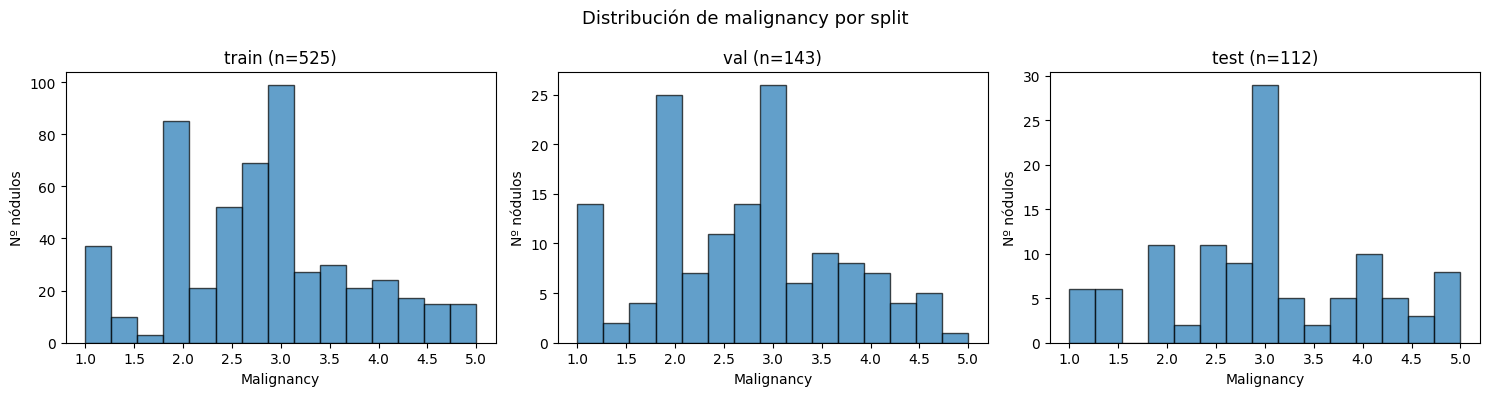

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, s in enumerate(["train", "val", "test"]):
    csv_path = os.path.join(output_dir, "preprocessed", s, "metadata.csv")
    if not os.path.exists(csv_path):
        axes[i].set_title(f"{s} — no encontrado")
        continue
    m = pd.read_csv(csv_path)
    axes[i].hist(m["malignancy"], bins=15, edgecolor="black", alpha=0.7)
    axes[i].set_xlabel("Malignancy")
    axes[i].set_ylabel("Nº nódulos")
    axes[i].set_title(f"{s} (n={len(m)})")

plt.suptitle("Distribución de malignancy por split", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Visualizar un nódulo preprocesado

Cambia `nodule_row` para explorar otros nódulos.

In [ ]:
nodule_row = 1  # <-- cambia este valor

row = meta.iloc[nodule_row]
fname = f"{row.patient_id}.npy"

ct = np.load(os.path.join(split_dir, "CT", fname))
mask = np.load(os.path.join(split_dir, "masks", fname))

print(f"Paciente: {row.patient_id}")
print(f"Nódulo: {int(row.nodule_idx)}")
print(f"Shape: {ct.shape}")
print(f"Rango CT: [{ct.min():.3f}, {ct.max():.3f}]")
print(f"Dtype CT: {ct.dtype}")
print(f"Valores máscara: {np.unique(mask)}")
print(f"Malignancy: {row.malignancy}")

FileNotFoundError: [Errno 2] No such file or directory: '../../output\\preprocessed\\train\\CT\\LIDC-IDRI-0069_nod1.npy'

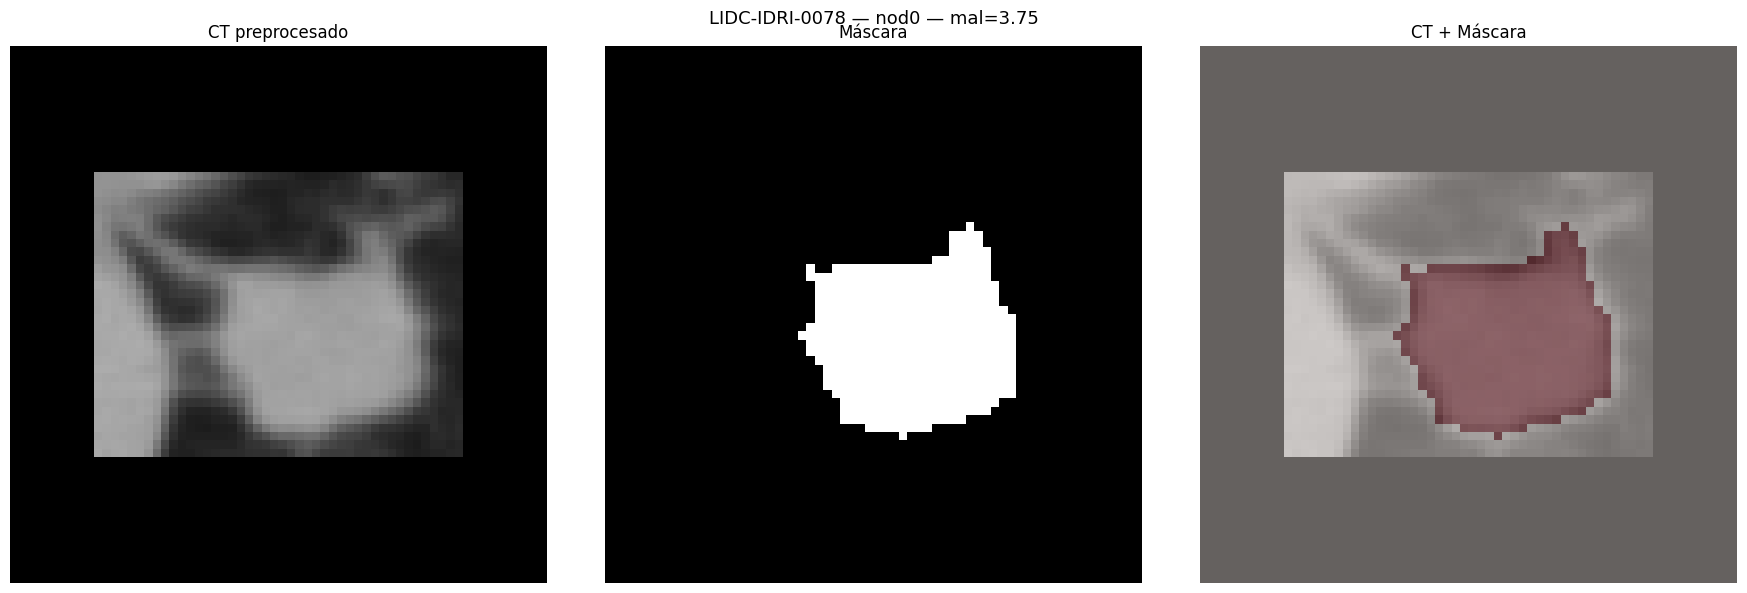

In [7]:
# Slice central: CT, máscara y overlay
z = ct.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct[:, :, z], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("CT preprocesado")
axes[0].axis("off")

axes[1].imshow(mask[:, :, z], cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(ct[:, :, z], cmap="gray", vmin=0, vmax=1)
axes[2].imshow(mask[:, :, z], alpha=0.4, cmap="Reds")
axes[2].set_title("CT + Máscara")
axes[2].axis("off")

plt.suptitle(f"{row.patient_id} — nod{int(row.nodule_idx)} — mal={row.malignancy}", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Todos los slices del nódulo

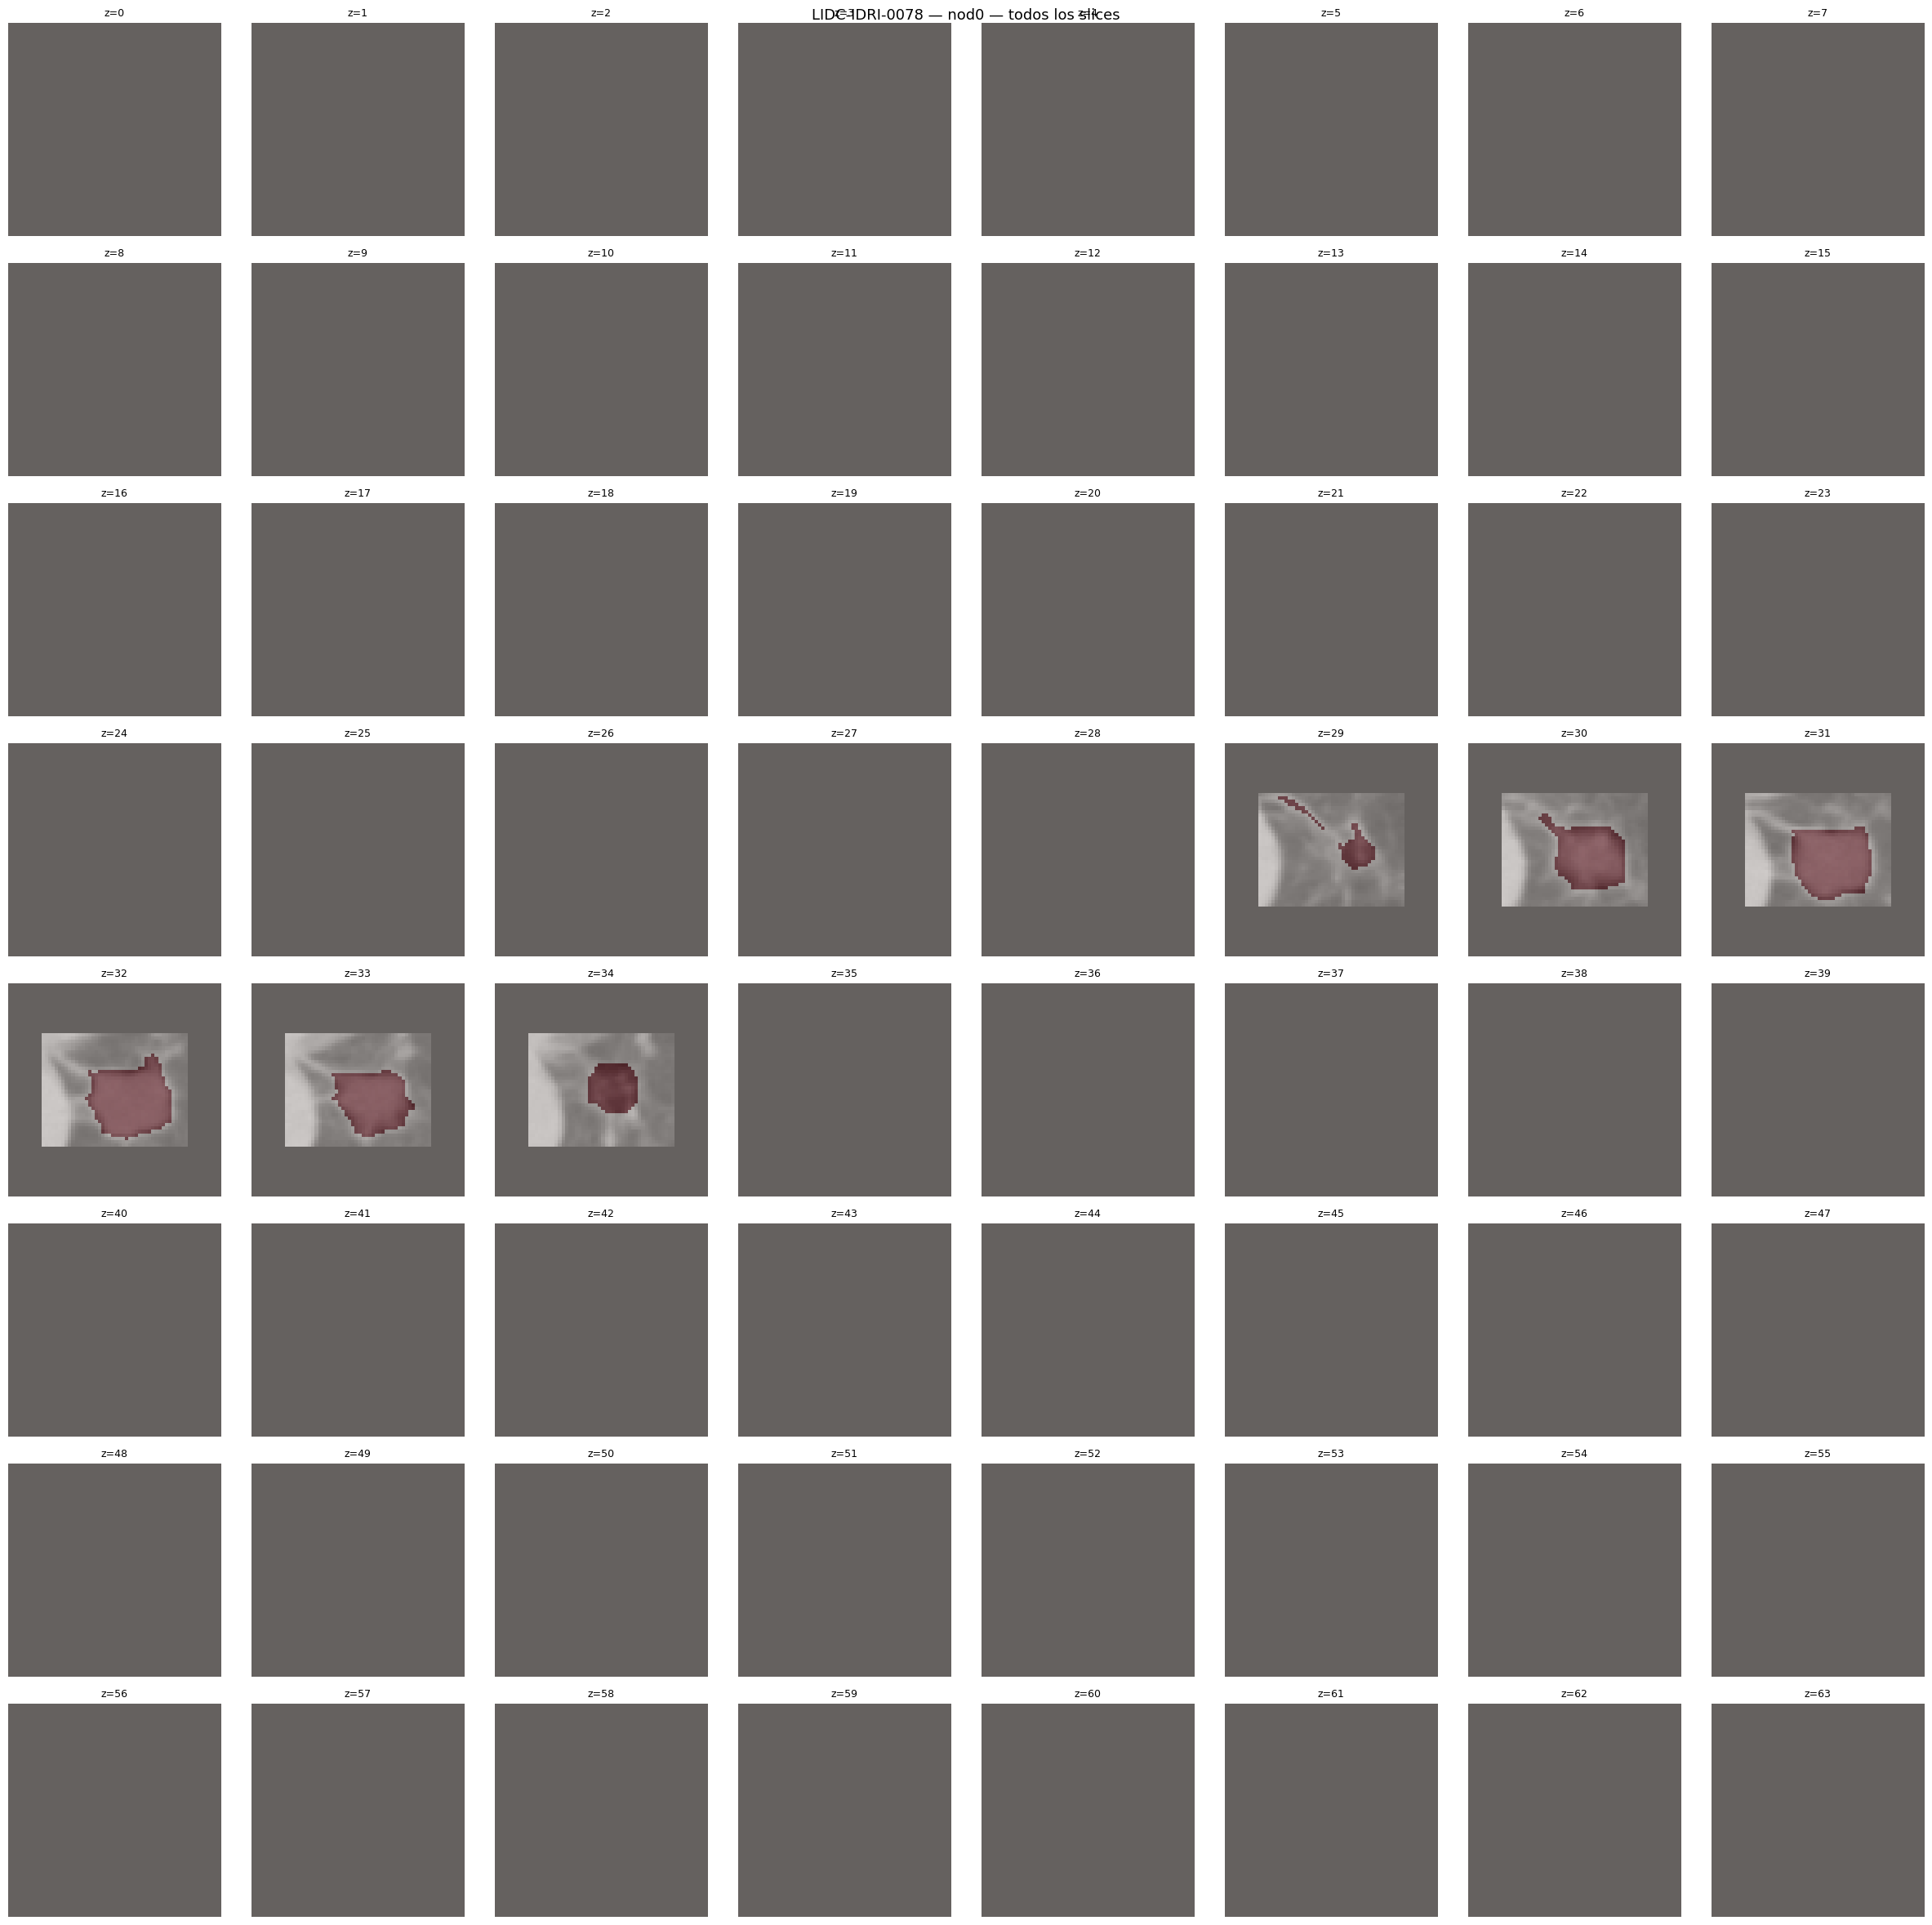

In [13]:
n_slices = ct.shape[2]
cols = min(n_slices, 8)
rows_grid = (n_slices + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(3 * cols, 3 * rows_grid))
axes = np.atleast_2d(axes)

for i in range(rows_grid * cols):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    if i < n_slices:
        ax.imshow(ct[:, :, i], cmap="gray", vmin=0, vmax=1)
        ax.imshow(mask[:, :, i], alpha=0.4, cmap="Reds")
        ax.set_title(f"z={i}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"{row.patient_id} — nod{int(row.nodule_idx)} — todos los slices", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Comparar varios nódulos del split

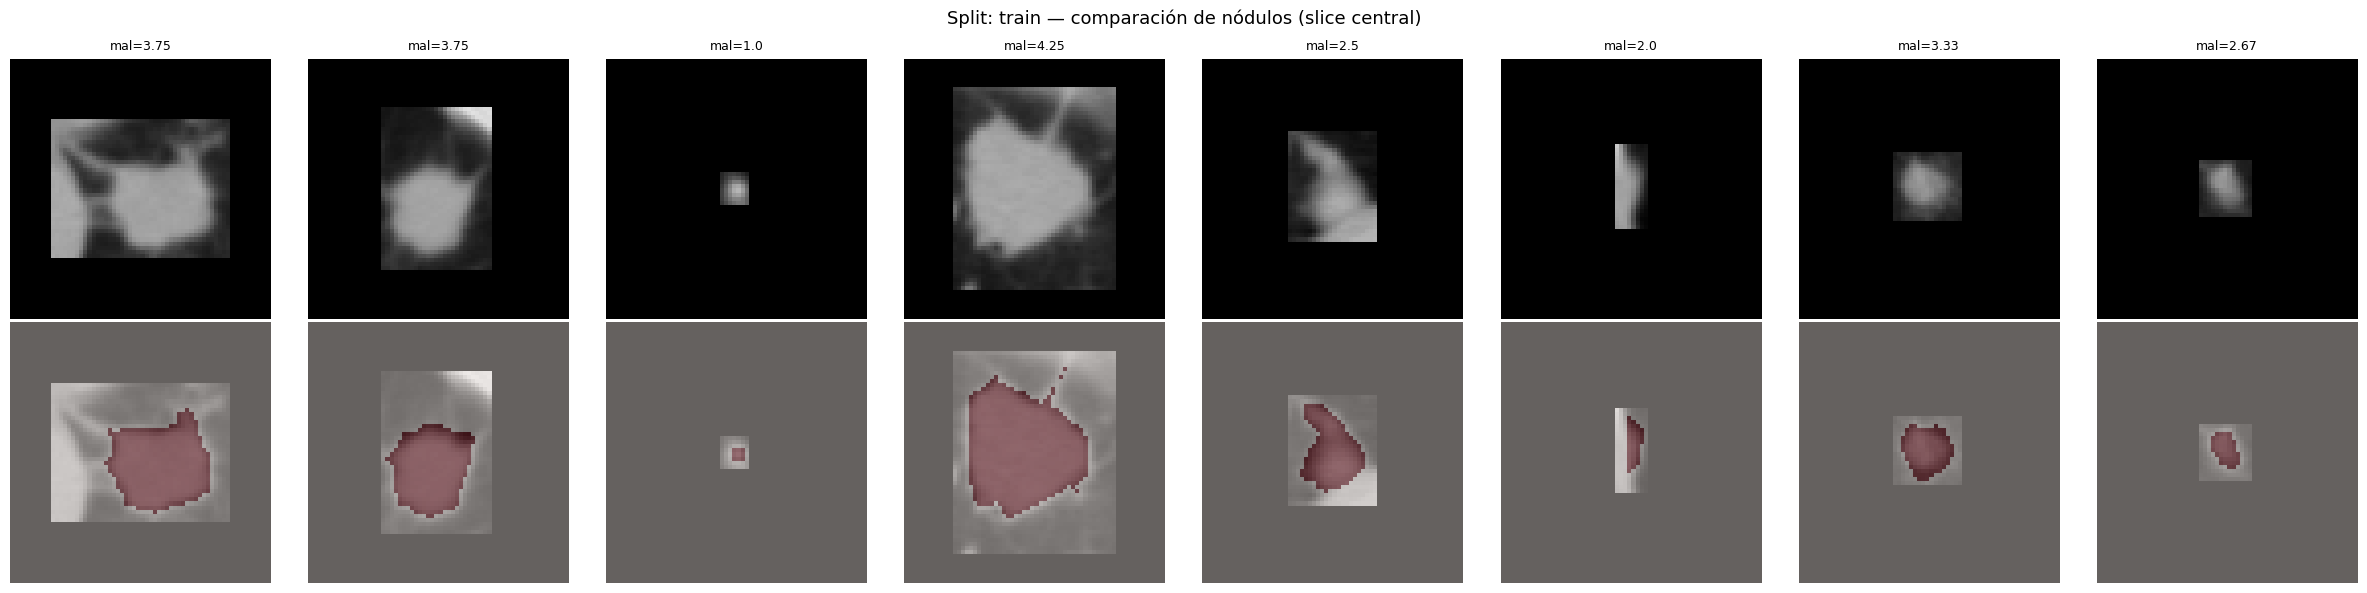

In [9]:
n_show = min(8, len(meta))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

for i in range(n_show):
    r = meta.iloc[i]
    f = f"{r.patient_id}_nod{int(r.nodule_idx)}.npy"
    ct_i = np.load(os.path.join(split_dir, "CT", f))
    mask_i = np.load(os.path.join(split_dir, "masks", f))
    z = ct_i.shape[2] // 2

    axes[0, i].imshow(ct_i[:, :, z], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"mal={r.malignancy}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(ct_i[:, :, z], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(mask_i[:, :, z], alpha=0.4, cmap="Reds")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("CT", fontsize=11)
axes[1, 0].set_ylabel("CT + Máscara", fontsize=11)
plt.suptitle(f"Split: {split} — comparación de nódulos (slice central)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Buscar por paciente

In [2]:
patient_id = "LIDC-IDRI-0078"  # <-- cambia el paciente

# Buscar en todos los splits
for s in ["train", "val", "test"]:
    csv_path = os.path.join(output_dir, "preprocessed", s, "metadata.csv")
    if not os.path.exists(csv_path):
        continue
    m = pd.read_csv(csv_path)
    paciente = m[m.patient_id == patient_id]
    if len(paciente) > 0:
        print(f"Encontrado en split: {s}")
        print(f"Nódulos: {len(paciente)}")
        print(paciente[["patient_id", "nodule_idx", "num_annotations", "malignancy"]].to_string(index=False))
        
        s_dir = os.path.join(output_dir, "preprocessed/train", s)
        for _, pr in paciente.iterrows():
            fn = f"{pr.patient_id}_nod{int(pr.nodule_idx)}.npy"
            ct_p = np.load(os.path.join(s_dir, "CT", fn))
            mask_p = np.load(os.path.join(s_dir, "masks", fn))
            zz = ct_p.shape[2] // 2
            
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            ax[0].imshow(ct_p[:, :, zz], cmap="gray", vmin=0, vmax=1)
            ax[0].set_title("CT")
            ax[0].axis("off")
            ax[1].imshow(mask_p[:, :, zz], cmap="gray")
            ax[1].set_title("Máscara")
            ax[1].axis("off")
            ax[2].imshow(ct_p[:, :, zz], cmap="gray", vmin=0, vmax=1)
            ax[2].imshow(mask_p[:, :, zz], alpha=0.4, cmap="Reds")
            ax[2].set_title("Overlay")
            ax[2].axis("off")
            plt.suptitle(f"{pr.patient_id} nod{int(pr.nodule_idx)} — mal={pr.malignancy}", fontsize=13)
            plt.tight_layout()
            plt.show()
        break
else:
    print(f"Paciente {patient_id} no encontrado en ningún split")

NameError: name 'output_dir' is not defined